# 04 — Layer 2b: Machine Learning Models
## Linear Regression · Elastic Net · SVR · Random Forest · XGBoost

### Purpose
Train and evaluate five ML regression models to predict GDP growth
using lagged macroeconomic indicators. 5-fold cross-validation on
train set. Period-by-period evaluation on test set. SHAP explainability
for XGBoost. Compare all models against Layer 2a baseline.

### Input
- `../data/03_panel_instability.csv`

### Output
- `../models/` — 5 trained model .pkl files + scaler.pkl
- `../data/layer2b_results.csv`
- `../data/layer2b_feature_importance.csv`
- 5 diagnostic plots + SHAP plots

### Run after → Run before
`03_layer2a_econometric.ipynb` → `05_layer3_lstm.ipynb`

In [52]:
import os
import gc
import joblib
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
os.makedirs("models", exist_ok=True)

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_validate

import xgboost as xgb

df = pd.read_csv("data/03_panel_instability.csv")
df = df.sort_values(["COUNTRY", "YEAR"]).copy()

print(f"Loaded: {df.shape}")
print(f"Countries: {df['COUNTRY'].nunique()}")
print(f"Years: {df['YEAR'].min()}-{df['YEAR'].max()}")

Loaded: (4982, 101)
Countries: 175
Years: 1998-2026


In [53]:
base_feature_cols = [
    "GDP_Growth_lag1",
    "GDP_Growth_rollmean3",
    "Inflation_lag1_log",
    "Exports_lag1",
    "Imports_lag1",
    "Fiscal_Balance_lag1",
    "Current_Account_lag1",
    "Debt_diff_lag1",
    "Expenditure_diff_lag1",
    "Revenue_diff_lag1",
    "Savings_diff_lag1",
    "Investment_diff_lag1",
    "Instability_Index_lag1",
]

volatility_cols = [
    col for col in [
        "GDP_Growth_rollstd3",
        "Inflation_rollstd3",
        "Exports_rollstd3",
        "Imports_rollstd3",
        "Fiscal_Balance_rollstd3",
        "Current_Account_rollstd3",
        "Debt_rollstd3",
        "Revenue_rollstd3",
        "Expenditure_rollstd3",
        "Savings_rollstd3",
        "Investment_rollstd3",
    ]
    if col in df.columns
]

feature_cols = base_feature_cols + volatility_cols

df_model = df.dropna(
    subset=feature_cols + ["GDP_Growth"]
).copy()

print(f"Model dataset: {df_model.shape}")
print(f"Features used: {len(feature_cols)}")
print("Volatility features:", volatility_cols)

Model dataset: (4807, 101)
Features used: 24
Volatility features: ['GDP_Growth_rollstd3', 'Inflation_rollstd3', 'Exports_rollstd3', 'Imports_rollstd3', 'Fiscal_Balance_rollstd3', 'Current_Account_rollstd3', 'Debt_rollstd3', 'Revenue_rollstd3', 'Expenditure_rollstd3', 'Savings_rollstd3', 'Investment_rollstd3']


In [54]:
TRAIN_END = 2019
TEST_START = 2022
TEST_END = 2023

train = df_model[df_model["YEAR"] <= TRAIN_END].copy()

test = df_model[
    (df_model["YEAR"] >= TEST_START)
    & (df_model["YEAR"] <= TEST_END)
].copy()

projection = df_model[
    df_model["YEAR"].isin([2024, 2025, 2026])
].copy()

X_train = train[feature_cols].to_numpy()
y_train = train["GDP_Growth"].to_numpy()

X_test = test[feature_cols].to_numpy()
y_test = test["GDP_Growth"].to_numpy()

X_projection = projection[feature_cols].to_numpy()

print(f"Train: {train['YEAR'].min()}-{train['YEAR'].max()} | n={len(train)}")
print(f"Observed test: {test['YEAR'].min()}-{test['YEAR'].max()} | n={len(test)}")
print(f"Projection: 2024-2026 | n={len(projection)}")

Train: 1999-2019 | n=3602
Observed test: 2022-2023 | n=346
Projection: 2024-2026 | n=513


In [55]:
train_years = train["YEAR"].to_numpy(copy=False)

validation_years = [2015, 2016, 2017, 2018, 2019]

time_splits = []

for validation_year in validation_years:
    train_idx = np.flatnonzero(train_years < validation_year)
    valid_idx = np.flatnonzero(train_years == validation_year)

    if len(train_idx) > 0 and len(valid_idx) > 0:
        time_splits.append((train_idx, valid_idx))

        print(
            f"Fold {validation_year}: "
            f"train={len(train_idx)}, validation={len(valid_idx)}"
        )

Fold 2015: train=2733, validation=173
Fold 2016: train=2906, validation=174
Fold 2017: train=3080, validation=174
Fold 2018: train=3254, validation=174
Fold 2019: train=3428, validation=174


In [56]:
models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "scaled": True,
    },

    "Elastic Net": {
        "model": ElasticNetCV(
            l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0],
            cv=5,
            max_iter=10000,
            random_state=42,
        ),
        "scaled": True,
    },

    "SVR": {
        "model": SVR(
            kernel="rbf",
            C=1.0,
            epsilon=0.1,
            gamma="scale",
        ),
        "scaled": True,
    },

    "Random Forest": {
        "model": RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=1,
        ),
        "scaled": False,
    },

    "XGBoost": {
        "model": xgb.XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbosity=0,
            n_jobs=1,
        ),
        "scaled": False,
    },
}

print("Models defined:")
for name in models:
    print(" -", name)

Models defined:
 - Linear Regression
 - Elastic Net
 - SVR
 - Random Forest
 - XGBoost


In [57]:
trained = {}
cv_rows = []

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

for name, cfg in models.items():
    print(f"\nTraining {name}...")

    estimator = clone(cfg["model"])

    if cfg["scaled"]:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", estimator),
        ])
    else:
        pipeline = Pipeline([
            ("model", estimator),
        ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=time_splits,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    cv_rmse = -scores["test_rmse"]
    cv_mae = -scores["test_mae"]
    cv_r2 = scores["test_r2"]

    cv_rows.append({
        "Model": name,
        "CV_RMSE": round(cv_rmse.mean(), 3),
        "CV_RMSE_std": round(cv_rmse.std(), 3),
        "CV_MAE": round(cv_mae.mean(), 3),
        "CV_MAE_std": round(cv_mae.std(), 3),
        "CV_R2": round(cv_r2.mean(), 3),
        "CV_R2_std": round(cv_r2.std(), 3),
    })

    pipeline.fit(X_train, y_train)
    trained[name] = pipeline

    filename = name.lower().replace(" ", "_")
    joblib.dump(pipeline, f"models/{filename}.pkl")

    print(
        f"{name:<20} "
        f"CV RMSE={cv_rmse.mean():.3f} | "
        f"CV MAE={cv_mae.mean():.3f} | "
        f"CV R2={cv_r2.mean():.3f}"
    )

    gc.collect()

cv_results_df = pd.DataFrame(cv_rows)
cv_results_df.to_csv("data/layer2b_cv_results.csv", index=False)

display(cv_results_df.sort_values("CV_RMSE"))


Training Linear Regression...
Linear Regression    CV RMSE=3.465 | CV MAE=2.061 | CV R2=0.123

Training Elastic Net...
Elastic Net          CV RMSE=3.432 | CV MAE=2.038 | CV R2=0.141

Training SVR...
SVR                  CV RMSE=3.447 | CV MAE=1.878 | CV R2=0.138

Training Random Forest...
Random Forest        CV RMSE=3.337 | CV MAE=1.841 | CV R2=0.194

Training XGBoost...
XGBoost              CV RMSE=3.265 | CV MAE=1.919 | CV R2=0.224


,Model,CV_RMSE,CV_RMSE_std,CV_MAE,CV_MAE_std,CV_R2,CV_R2_std
4,XGBoost,3.265,0.537,1.919,0.294,0.224,0.152
3,Random Forest,3.337,0.578,1.841,0.267,0.194,0.146
1,Elastic Net,3.432,0.612,2.038,0.281,0.141,0.191
2,SVR,3.447,0.419,1.878,0.256,0.138,0.065
0,Linear Regression,3.465,0.653,2.061,0.296,0.123,0.219


In [58]:
def eval_period(name, y_true, y_pred, period):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt = y_true[mask]
    yp = y_pred[mask]

    return {
        "Model": name,
        "Period": period,
        "N": len(yt),
        "RMSE": round(np.sqrt(mean_squared_error(yt, yp)), 3),
        "MAE": round(mean_absolute_error(yt, yp), 3),
        "R2": round(r2_score(yt, yp), 3),
        "Mean_Actual": round(float(yt.mean()), 2),
        "Mean_Predicted": round(float(yp.mean()), 2),
        "Mean_Error": round(float((yt - yp).mean()), 2),
    }


test_years = test["YEAR"].to_numpy(copy=False)

period_masks = {
    "Post-COVID test (2022-23)": np.isin(test_years, [2022, 2023]),
    "Year 2022": test_years == 2022,
    "Year 2023": test_years == 2023,
}

all_results = []
predictions = {}

for name, pipeline in trained.items():
    pred_test = pipeline.predict(X_test)
    predictions[name] = pred_test

    for period, mask in period_masks.items():
        result = eval_period(
            name,
            y_test[mask],
            pred_test[mask],
            period,
        )

        all_results.append(result)

results_df = pd.DataFrame(all_results)

results_df.to_csv(
    "data/layer2b_results.csv",
    index=False,
)

display(
    results_df[
        results_df["Period"] == "Post-COVID test (2022-23)"
    ].sort_values("RMSE")
)

,Model,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
9,Random Forest,Post-COVID test (2022-23),346,4.591,2.634,0.278,3.81,4.20,-0.38
3,Elastic Net,Post-COVID test (2022-23),346,4.814,2.706,0.207,3.81,3.42,0.39
0,Linear Regression,Post-COVID test (2022-23),346,4.875,2.785,0.186,3.81,3.20,0.61
12,XGBoost,Post-COVID test (2022-23),346,4.932,2.828,0.167,3.81,4.24,-0.43
6,SVR,Post-COVID test (2022-23),346,5.301,2.785,0.038,3.81,4.21,-0.40


In [59]:
projection_df = projection[["COUNTRY", "YEAR"]].reset_index(drop=True)

for name, pipeline in trained.items():
    projection_df[f"{name}_Forecast"] = pipeline.predict(X_projection)

projection_df.to_csv(
    "data/layer2b_forecasts_2024_2026.csv",
    index=False,
)

print("Saved: data/layer2b_forecasts_2024_2026.csv")
print(projection_df.head())

Saved: data/layer2b_forecasts_2024_2026.csv
                            COUNTRY  YEAR  Linear Regression_Forecast  \
0  Afghanistan, Islamic Republic of  2024                    1.107932   
1  Afghanistan, Islamic Republic of  2025                    1.401975   
2                           Albania  2024                    5.634013   
3                           Albania  2025                    3.916449   
4                           Albania  2026                    3.524157   

   Elastic Net_Forecast  SVR_Forecast  Random Forest_Forecast  \
0              1.684504      3.356104                2.493745   
1              1.994013      4.486222                2.665890   
2              5.320624      5.743173                4.494873   
3              3.852363      4.009677                3.958641   
4              3.478335      3.511082                3.582855   

   XGBoost_Forecast  
0          3.073055  
1          2.448527  
2          5.980361  
3          4.160661  
4          3.122

In [60]:
layer2a_results = pd.read_csv("data/layer2a_results.csv")
layer2b_results = pd.read_csv("data/layer2b_results.csv")

main_2b = layer2b_results[
    layer2b_results["Period"] == "Post-COVID test (2022-23)"
].copy()

best_2a = layer2a_results.loc[
    layer2a_results["RMSE"].idxmin()
]

best_2b = main_2b.loc[
    main_2b["RMSE"].idxmin()
]

improvement = (
    (best_2a["RMSE"] - best_2b["RMSE"])
    / best_2a["RMSE"]
    * 100
)

comparison_summary = pd.DataFrame([
    {
        "Layer": "2a Econometric",
        "Best_Model": best_2a["Model"],
        "RMSE": best_2a["RMSE"],
        "MAE": best_2a["MAE"],
        "R2": best_2a["R2"],
    },
    {
        "Layer": "2b ML",
        "Best_Model": best_2b["Model"],
        "RMSE": best_2b["RMSE"],
        "MAE": best_2b["MAE"],
        "R2": best_2b["R2"],
    },
])

comparison_summary["ML_Improvement_%"] = np.nan
comparison_summary.loc[
    comparison_summary["Layer"] == "2b ML",
    "ML_Improvement_%",
] = round(improvement, 2)

comparison_summary.to_csv(
    "data/layer2a_vs_2b_summary.csv",
    index=False,
)

display(comparison_summary)

print(f"Best Layer 2a: {best_2a['Model']} | RMSE={best_2a['RMSE']:.3f}")
print(f"Best Layer 2b: {best_2b['Model']} | RMSE={best_2b['RMSE']:.3f}")
print(f"ML improvement: {improvement:.2f}%")

,Layer,Best_Model,RMSE,MAE,R2,ML_Improvement_%
0,2a Econometric,Pooled OLS,4.779,2.725,0.218,NaN
1,2b ML,Random Forest,4.591,2.634,0.278,3.93


Best Layer 2a: Pooled OLS | RMSE=4.779
Best Layer 2b: Random Forest | RMSE=4.591
ML improvement: 3.93%


The ML layer does not dramatically outperform the econometric baseline, but it provides a modest improvement in out-of-sample predictive accuracy. Random Forest reduced RMSE by 3.93% relative to the best econometric model and improved R² from 0.218 to 0.278, suggesting that nonlinear interactions add some predictive value, although GDP growth remains difficult to forecast precisely.

In [61]:
covid_test = df_model[
    df_model["YEAR"].isin([2020, 2021])
].copy()

X_covid = covid_test[feature_cols].to_numpy()
y_covid = covid_test["GDP_Growth"].to_numpy()

covid_rows = []

for name, pipeline in trained.items():
    pred = pipeline.predict(X_covid)

    covid_rows.append({
        "Model": name,
        "Period": "COVID stress test (2020-21)",
        "N": len(y_covid),
        "RMSE": round(np.sqrt(mean_squared_error(y_covid, pred)), 3),
        "MAE": round(mean_absolute_error(y_covid, pred), 3),
        "R2": round(r2_score(y_covid, pred), 3),
    })

covid_results_df = pd.DataFrame(covid_rows)

covid_results_df.to_csv(
    "data/covid_stress_test_results.csv",
    index=False,
)

display(covid_results_df.sort_values("RMSE"))

,Model,Period,N,RMSE,MAE,R2
3,Random Forest,COVID stress test (2020-21),346,8.646,6.590,-0.076
2,SVR,COVID stress test (2020-21),346,8.765,6.526,-0.106
4,XGBoost,COVID stress test (2020-21),346,8.837,6.793,-0.124
1,Elastic Net,COVID stress test (2020-21),346,9.154,6.872,-0.206
0,Linear Regression,COVID stress test (2020-21),346,9.202,6.904,-0.219


In [62]:
# ============================================================
# Feature Importance
# ============================================================

rf_model = trained["Random Forest"].named_steps["model"]
xgb_model = trained["XGBoost"].named_steps["model"]
en_model = trained["Elastic Net"].named_steps["model"]

rf_imp = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols,
    name="Random Forest",
).sort_values(ascending=False)

xgb_imp = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols,
    name="XGBoost",
).sort_values(ascending=False)

en_coef = pd.Series(
    en_model.coef_,
    index=feature_cols,
    name="Elastic Net",
).sort_values(key=np.abs, ascending=False)

print("Random Forest top 10:")
print(rf_imp.head(10).round(4))

print("\nXGBoost top 10:")
print(xgb_imp.head(10).round(4))

print("\nElastic Net non-zero coefficients:")
print(en_coef[en_coef != 0].round(4).to_string())

importance_df = pd.concat(
    [rf_imp, xgb_imp, en_coef],
    axis=1,
)

importance_df.index.name = "Feature"

importance_df.to_csv(
    "data/layer2b_feature_importance.csv"
)

print("\nSaved: data/layer2b_feature_importance.csv")

Random Forest top 10:
GDP_Growth_lag1         0.3690
GDP_Growth_rollmean3    0.2347
Imports_lag1            0.0580
Exports_lag1            0.0344
Inflation_lag1_log      0.0322
Exports_rollstd3        0.0293
Expenditure_rollstd3    0.0289
Debt_diff_lag1          0.0215
Current_Account_lag1    0.0207
Savings_diff_lag1       0.0204
Name: Random Forest, dtype: float64

XGBoost top 10:
GDP_Growth_lag1          0.1035
GDP_Growth_rollmean3     0.0713
Investment_rollstd3      0.0703
Expenditure_rollstd3     0.0618
Fiscal_Balance_lag1      0.0529
Savings_diff_lag1        0.0503
Imports_lag1             0.0453
Exports_rollstd3         0.0452
Expenditure_diff_lag1    0.0443
Investment_diff_lag1     0.0410
Name: XGBoost, dtype: float32

Elastic Net non-zero coefficients:
GDP_Growth_rollmean3        1.5462
GDP_Growth_lag1             0.5236
Savings_diff_lag1           0.4358
Investment_diff_lag1       -0.3303
Investment_rollstd3         0.2998
Revenue_diff_lag1          -0.2876
Exports_lag1       

Maximum reconstruction difference: 1.335144e-05


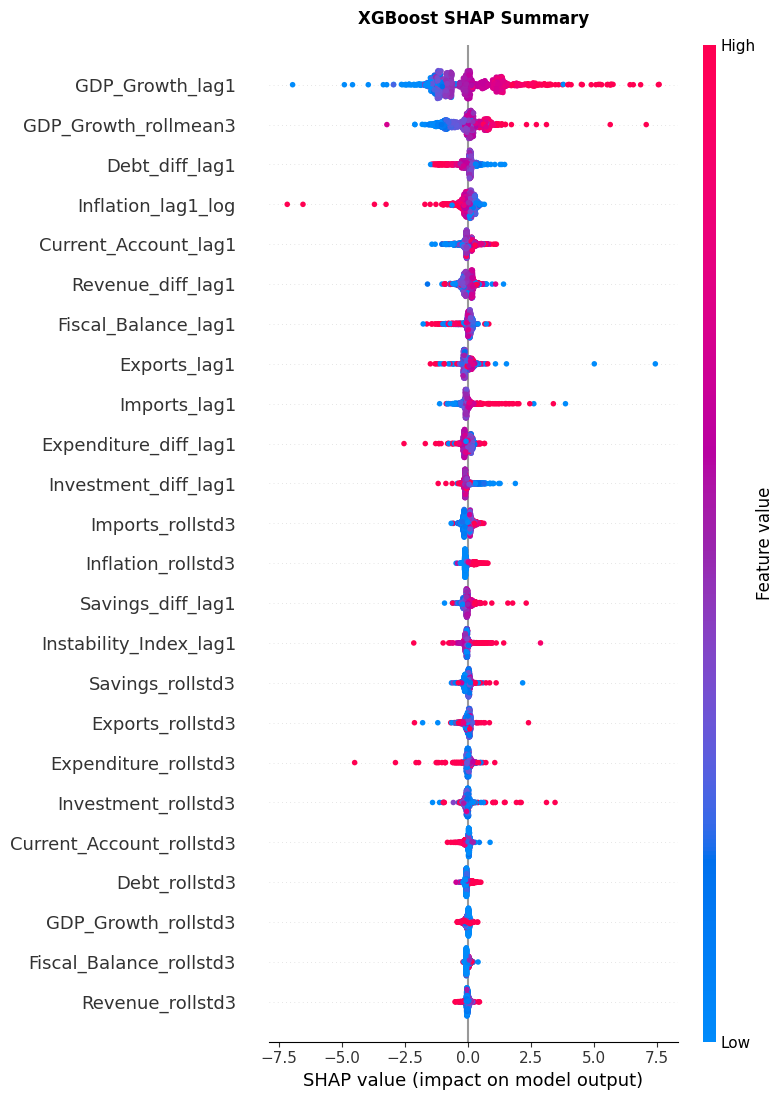

SHAP observations used: 1000
Saved: layer2b_shap_summary.png
Saved: models/shap_values_xgboost_train.npy
Saved: models/shap_base_values_xgboost_train.npy


In [63]:
# -- Native XGBoost SHAP values --------------------------------

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Extract XGBoost from the fitted pipeline
xgb_model = trained["XGBoost"].named_steps["model"]

# Sample training rows to limit memory use
rng = np.random.default_rng(42)
sample_size = min(1000, len(X_train))

sample_indices = rng.choice(
    len(X_train),
    size=sample_size,
    replace=False
)

X_shap = pd.DataFrame(
    X_train[sample_indices],
    columns=feature_cols
)

# Create XGBoost's native data structure
dmat = xgb.DMatrix(
    X_shap,
    feature_names=feature_cols
)

# Native SHAP contributions
# Last column is the expected/base value
contributions = xgb_model.get_booster().predict(
    dmat,
    pred_contribs=True
)

shap_values = contributions[:, :-1]
base_values = contributions[:, -1]

# Validation: SHAP contributions should reconstruct predictions
native_predictions = xgb_model.predict(X_shap)
reconstructed_predictions = (
    shap_values.sum(axis=1) + base_values
)

print(
    "Maximum reconstruction difference:",
    np.max(
        np.abs(
            native_predictions - reconstructed_predictions
        )
    )
)

# Save calculated values
np.save(
    "models/shap_values_xgboost_train.npy",
    shap_values
)

np.save(
    "models/shap_base_values_xgboost_train.npy",
    base_values
)

X_shap.to_csv(
    "data/shap_xgboost_sample.csv",
    index=False
)

# SHAP summary plot
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_cols,
    max_display=len(feature_cols),
    show=False
)

plt.title(
    "XGBoost SHAP Summary",
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    "layer2b_shap_summary.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"SHAP observations used: {sample_size}")
print("Saved: layer2b_shap_summary.png")
print("Saved: models/shap_values_xgboost_train.npy")
print("Saved: models/shap_base_values_xgboost_train.npy")

In [64]:
shap_check = X_shap.copy()
shap_check["SHAP_GDP_rollmean3"] = shap_values[
    :, feature_cols.index("GDP_Growth_rollmean3")
]

shap_check.nlargest(
    10, "SHAP_GDP_rollmean3"
)[
    ["GDP_Growth_rollmean3", "SHAP_GDP_rollmean3"]
]

,GDP_Growth_rollmean3,SHAP_GDP_rollmean3
730,23.373333,7.089495
198,65.641000,5.661983
150,18.366333,3.129142
509,18.021667,2.728729
958,14.027000,2.337759
777,17.685333,1.738354
10,16.183000,1.499681
18,9.643333,1.494820
45,11.864000,1.374490
235,10.014000,1.371370


In [65]:
df.loc[
    df["GDP_Growth_rollmean3"] > 25,
    ["COUNTRY", "YEAR", "GDP_Growth", "GDP_Growth_lag1",
     "GDP_Growth_rollmean3"]
].sort_values("GDP_Growth_rollmean3", ascending=False)

,COUNTRY,YEAR,GDP_Growth,GDP_Growth_lag1,GDP_Growth_rollmean3
1440,"Equatorial Guinea, Republic of",1998,24.815,147.973,75.720333
1441,"Equatorial Guinea, Republic of",1999,26.395,24.815,75.155333
1442,"Equatorial Guinea, Republic of",2000,110.505,26.395,66.394333
1444,"Equatorial Guinea, Republic of",2002,19.621,60.023,65.641000
1445,"Equatorial Guinea, Republic of",2003,14.455,19.621,63.383000
1443,"Equatorial Guinea, Republic of",2001,60.023,110.505,53.905000
1924,Guyana,2025,19.309,43.776,46.959667
1922,Guyana,2023,33.769,63.334,42.291333
1923,Guyana,2024,43.776,33.769,39.054333
542,Bosnia and Herzegovina,1998,13.814,22.853,35.242333


The years 2024–2026 are IMF projection years. They are not used for model accuracy evaluation. They are used only to generate scenario-style GDP growth forecasts.